##  Google Drive Mount 

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print(" Google Drive mounted!")


Mounted at /content/drive
 Google Drive mounted!


##  ZIP Extract 


In [2]:
import zipfile
import os

ZIP_PATH    = "/content/drive/MyDrive/scenario23_dev_w_resources.zip"
EXTRACT_DIR = "/content/scenario23"

if not os.path.exists(EXTRACT_DIR):
    print("Extracting zip file...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print(" Extraction complete!")
else:
    print(" Already extracted.")


print("\n Extracted files:")
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:5]:
            print(f"  {indent}{f}")
        if len(files) > 5:
            print(f"  {indent}... ({len(files)} files total)")


Extracting zip file...
 Extraction complete!

 Extracted files:
scenario23/
  scenario23_dev/
    scenario23.csv
    resources/
      bbox_labels_final/
    unit1/
      camera_data/
      GPS_data/
      mmWave_data/
    unit2/
      altitude/
      height/
      distance/
      y_speed/
      z_speed/
      roll/
      GPS_data/
      speed/
      x_speed/
      pitch/


 CSV ও Image Folder search 

In [3]:
import glob

# CSV files 
csv_files = glob.glob(EXTRACT_DIR + "/**/*.csv", recursive=True)
print("CSV files found:")
for f in csv_files:
    print(" ", f)

# Image folder 
img_folders = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    imgs = [f for f in files if f.endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        img_folders.append((root, len(imgs)))

print("\nImage folders found:")
for folder, count in img_folders:
    print(f"  {folder}  ({count} images)")


CSV files found:
  /content/scenario23/scenario23_dev/scenario23.csv

Image folders found:
  /content/scenario23/scenario23_dev/unit1/camera_data  (11387 images)


In [4]:
import pandas as pd

#  path  thik kori 

# CSV path upor er output 
CSV_PATH  = csv_files[0]   # first CSV nilam 

# Image folder — unit1 (base station) এর RGB images
IMAGE_DIR = img_folders[0][0] if img_folders else ""

print(f"CSV  : {CSV_PATH}")
print(f"Images: {IMAGE_DIR}")

# ── CSV load ──────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f"\nShape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
df.head(3)


CSV  : /content/scenario23/scenario23_dev/scenario23.csv
Images: /content/scenario23/scenario23_dev/unit1/camera_data

Shape: (11387, 17)

Columns:
['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc', 'unit2_speed', 'unit2_altitude', 'unit2_distance', 'unit2_height', 'unit2_x-speed', 'unit2_y-speed', 'unit2_z-speed', 'unit2_pitch', 'unit2_roll', 'seq_index', 'time_stamp[UTC]', 'unit1_beam_index']


,index,unit1_rgb,unit1_pwr_60ghz,unit1_loc,unit2_loc,unit2_speed,unit2_altitude,unit2_distance,unit2_height,unit2_x-speed,unit2_y-speed,unit2_z-speed,unit2_pitch,unit2_roll,seq_index,time_stamp[UTC],unit1_beam_index
0,1,./unit1/camera_data/image_BS1_1_16_58_42.jpg,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_1.txt,./unit2/speed/speed_1.txt,./unit2/altitude/altitude_1.txt,./unit2/distance/distance_1.txt,./unit2/height/height_1.txt,./unit2/x_speed/x_speed_1.txt,./unit2/y_speed/y_speed_1.txt,./unit2/z_speed/z_speed_1.txt,./unit2/pitch/pitch_1.txt,./unit2/roll/roll_1.txt,1,['16-58-42-0'],43
1,2,./unit1/camera_data/image_BS1_2_16_58_42.jpg,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_2.txt,./unit2/speed/speed_2.txt,./unit2/altitude/altitude_2.txt,./unit2/distance/distance_2.txt,./unit2/height/height_2.txt,./unit2/x_speed/x_speed_2.txt,./unit2/y_speed/y_speed_2.txt,./unit2/z_speed/z_speed_2.txt,./unit2/pitch/pitch_2.txt,./unit2/roll/roll_2.txt,1,['16-58-42-142'],43
2,3,./unit1/camera_data/image_BS1_3_16_58_42.jpg,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_3.txt,./unit2/speed/speed_3.txt,./unit2/altitude/altitude_3.txt,./unit2/distance/distance_3.txt,./unit2/height/height_3.txt,./unit2/x_speed/x_speed_3.txt,./unit2/y_speed/y_speed_3.txt,./unit2/z_speed/z_speed_3.txt,./unit2/pitch/pitch_3.txt,./unit2/roll/roll_3.txt,1,['16-58-42-284'],43


In [5]:
import numpy as np

def pick_numeric_col(keywords, exclude=()):
    candidates = [
        c for c in df.columns
        if any(k in c.lower() for k in keywords)
        and not any(x in c.lower() for x in exclude)
    ]
    if not candidates:
        return None

    best_col = None
    best_ratio = -1.0
    for c in candidates:
        numeric_ratio = pd.to_numeric(df[c], errors='coerce').notna().mean()
        if numeric_ratio > best_ratio:
            best_ratio = numeric_ratio
            best_col = c

    return best_col if best_ratio > 0.5 else None

# GPS / motion columns
COL_LAT  = pick_numeric_col(['lat'])
COL_LON  = pick_numeric_col(['lon'])
COL_HGT  = pick_numeric_col(['height', 'alt'], exclude=['file', 'path', 'image', 'img'])
COL_DIST = pick_numeric_col(['dist'])
COL_SPD  = pick_numeric_col(['speed'])

# Image filename column
COL_IMG  = next((c for c in df.columns if 'rgb'  in c.lower()
                  or 'image' in c.lower() or 'img' in c.lower()), None)

print(f"Latitude  : {COL_LAT}")
print(f"Longitude : {COL_LON}")
print(f"Height    : {COL_HGT}")
print(f"Distance  : {COL_DIST}")
print(f"Speed     : {COL_SPD}")
print(f"Image col : {COL_IMG}")

# ── Beam power columns ────────────────────────────────────────────────────────
beam_cols = [c for c in df.columns if 'beam' in c.lower() or 'pwr' in c.lower()
             or 'power' in c.lower() or 'unit1_pwr' in c.lower()]
print(f"\nBeam/Power columns ({len(beam_cols)}): {beam_cols[:6]} ...")


Latitude  : None
Longitude : None
Height    : unit2_altitude
Distance  : unit2_distance
Speed     : unit2_speed
Image col : unit1_rgb

Beam/Power columns (2): ['unit1_pwr_60ghz', 'unit1_beam_index'] ...


In [ ]:
#Optimal Beam Index 
beam_scores = df[beam_cols].apply(pd.to_numeric, errors='coerce')
if beam_scores.isna().all(axis=1).any():
    bad_rows = int(beam_scores.isna().all(axis=1).sum())
    raise ValueError(f"{bad_rows} rows have no numeric beam values after coercion.")
beam_scores = beam_scores.fillna(-np.inf)

if len(beam_cols) == 64:
    beam_cols_32 = beam_cols[::2]
    df['optimal_beam'] = beam_scores[beam_cols_32].to_numpy().argmax(axis=1)
    NUM_BEAMS = 32
    print(" 64 beams → 32 beams downsampled (paper method)")

elif len(beam_cols) == 32:
    beam_cols_32 = beam_cols
    df['optimal_beam'] = beam_scores[beam_cols].to_numpy().argmax(axis=1)
    NUM_BEAMS = 32
    print(" 32 beams used directly")

else:
    # Single packed column 
    print(f" {len(beam_cols)} beam columns found — unexpected format, using argmax on all")
    # Fallback
    beam_cols_32 = beam_cols
    df['optimal_beam'] = beam_scores[beam_cols].to_numpy().argmax(axis=1)
    NUM_BEAMS = len(beam_cols)

print(f"Number of beams : {NUM_BEAMS}")
print(f"Beam range      : {df['optimal_beam'].min()} – {df['optimal_beam'].max()}")
print(f"Total samples   : {len(df)}")


 2 beam columns found — unexpected format, using argmax on all
Number of beams : 2
Beam range      : 1 – 1
Total samples   : 11387


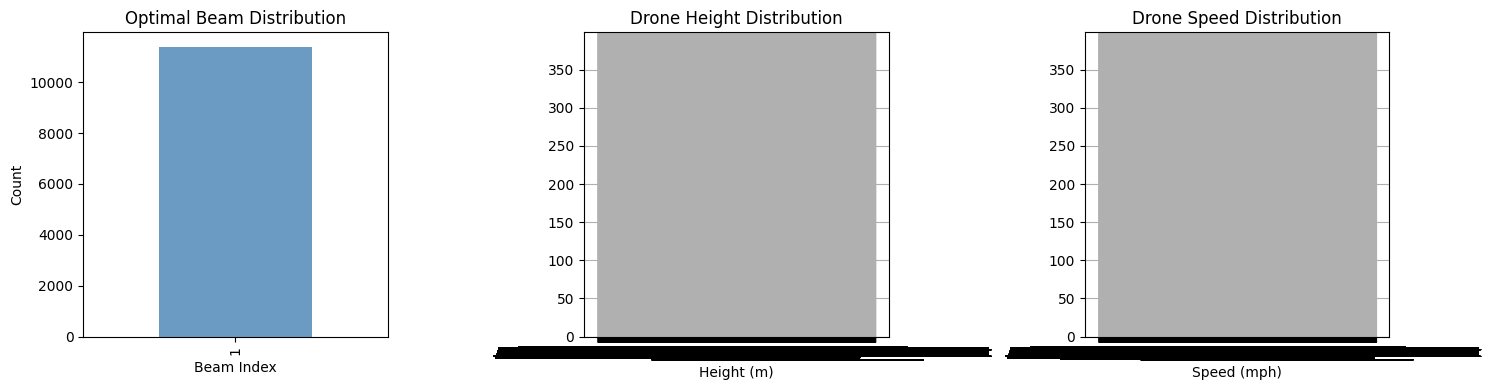

Dataset statistics:
       optimal_beam
count       11387.0
mean            1.0
std             0.0
min             1.0
25%             1.0
50%             1.0
75%             1.0
max             1.0


In [9]:
import matplotlib.pyplot as plt

# ── Distribution plot 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Beam distribution
df['optimal_beam'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title("Optimal Beam Distribution")
axes[0].set_xlabel("Beam Index"); axes[0].set_ylabel("Count")

# Height distribution
if COL_HGT and COL_HGT in df.columns:
    df[COL_HGT].hist(bins=30, ax=axes[1], color='coral', alpha=0.8)
    axes[1].set_title("Drone Height Distribution")
    axes[1].set_xlabel("Height (m)")

# Speed distribution
if COL_SPD and COL_SPD in df.columns:
    df[COL_SPD].hist(bins=30, ax=axes[2], color='green', alpha=0.7)
    axes[2].set_title("Drone Speed Distribution")
    axes[2].set_xlabel("Speed (mph)")

plt.tight_layout()
plt.show()
print(f"Dataset statistics:")
useful = [c for c in [COL_LAT, COL_LON, COL_HGT, COL_DIST, COL_SPD] if c]
print(df[useful + ['optimal_beam']].describe().round(3))


 Sample Image showing 

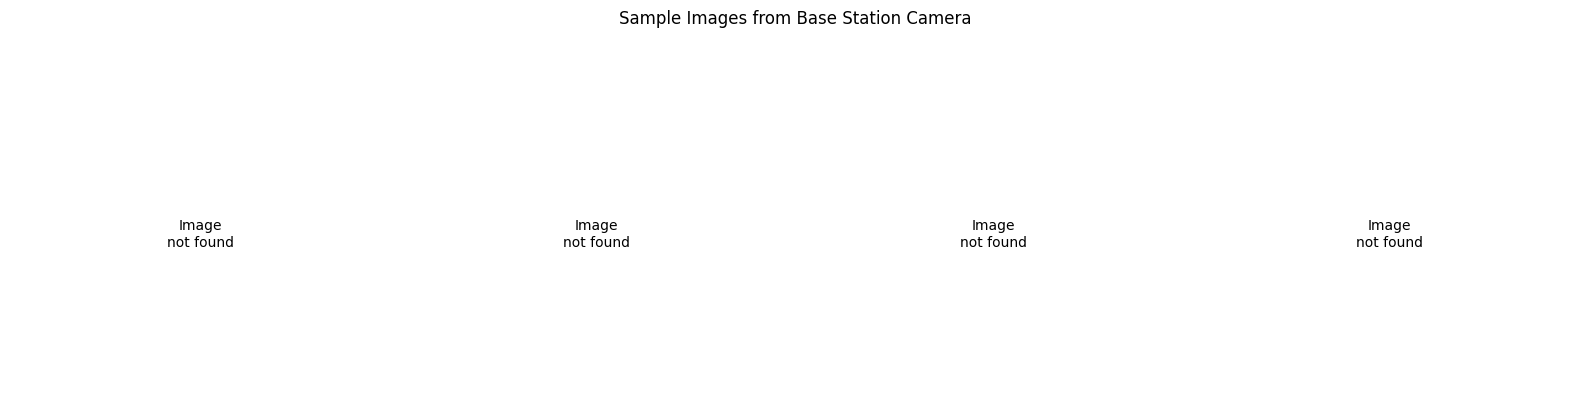

In [12]:
from PIL import Image
import os

if COL_IMG and IMAGE_DIR:
    
    sample_rows = df.sample(4, random_state=42)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, (_, row) in zip(axes, sample_rows.iterrows()):
        img_path = os.path.join(IMAGE_DIR, str(row[COL_IMG]))
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f"Beam: {int(row['optimal_beam'])}", fontsize=10)
        except:
            ax.text(0.5, 0.5, 'Image\nnot found',
                    ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
    plt.suptitle("Sample Images from Base Station Camera", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("  Image column or folder not found — skipping image preview")


##  Preprocessing ও Train/Test Split (70–30)

In [14]:
from sklearn.model_selection import train_test_split
#  Normalization
norm_cols = {}
for col, alias in [(COL_LAT,'lat'), (COL_LON,'lon'),
                   (COL_HGT,'hgt'), (COL_DIST,'dist')]:
    if col and col in df.columns:
        new_col = alias + '_norm'
        df[new_col] = (df[col] - df[col].mean()) / (df[col].std() + 1e-8)
        norm_cols[alias] = new_col
        print(f"Normalized: {col} → {new_col}")

# Split 
train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=42, shuffle=True)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTraining samples : {len(train_df)}")
print(f" Test samples     : {len(test_df)}")
print(f" Number of beams  : {NUM_BEAMS}")


TypeError: Could not convert string './unit2/altitude/altitude_1.txt./unit2/altitude/altitude_2.txt./unit2/altitude/altitude_3.txt./unit2/altitude/altitude_4.txt./unit2/altitude/altitude_5.txt./unit2/altitude/altitude_6.txt./unit2/altitude/altitude_7.txt./unit2/altitude/altitude_8.txt./unit2/altitude/altitude_9.txt./unit2/altitude/altitude_10.txt./unit2/altitude/altitude_11.txt./unit2/altitude/altitude_12.txt./unit2/altitude/altitude_13.txt./unit2/altitude/altitude_14.txt./unit2/altitude/altitude_15.txt./unit2/altitude/altitude_16.txt./unit2/altitude/altitude_17.txt./unit2/altitude/altitude_18.txt./unit2/altitude/altitude_19.txt./unit2/altitude/altitude_20.txt./unit2/altitude/altitude_21.txt./unit2/altitude/altitude_22.txt./unit2/altitude/altitude_23.txt./unit2/altitude/altitude_24.txt./unit2/altitude/altitude_25.txt./unit2/altitude/altitude_26.txt./unit2/altitude/altitude_27.txt./unit2/altitude/altitude_28.txt./unit2/altitude/altitude_29.txt./unit2/altitude/altitude_30.txt./unit2/alti

 Libraries Import (PyTorch, torchvision)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" PyTorch {torch.__version__}")
print(f" Device: {DEVICE}")


 Position-Aided Beam Prediction — MLP Model
**Paper Section III-B-1**  
Input: GPS (lat, lon) + height + distance → 512 → 512 → ReLU → Softmax → 32 beams


In [ ]:
class PositionDataset(Dataset):
    def __init__(self, dataframe, feature_cols, label_col='optimal_beam'):
        self.X = torch.tensor(
            dataframe[feature_cols].fillna(0).values.astype('float32'))
        self.y = torch.tensor(dataframe[label_col].values, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class MLP(nn.Module):
    """2-Layer MLP — Section III-B-1 of the paper."""
    def __init__(self, input_dim, num_classes, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x): return self.net(x)


# modalities 
MODALITIES = {}
if 'lat_norm' in norm_cols.values() and 'lon_norm' in norm_cols.values():
    MODALITIES['GPS only'] = [norm_cols['lat'], norm_cols['lon']]
if 'hgt_norm' in norm_cols.values():
    MODALITIES['GPS + Height'] = [norm_cols['lat'], norm_cols['lon'], norm_cols['hgt']]
if 'dist_norm' in norm_cols.values():
    MODALITIES['GPS + Height + Dist'] = [norm_cols['lat'], norm_cols['lon'],
                                          norm_cols['hgt'], norm_cols['dist']]

print("Modalities to train:")
for k, v in MODALITIES.items():
    print(f"  {k}: {v}")


In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr,
                lr_decay_epochs, device, model_name=""):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=lr_decay_epochs, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    history = {'loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward(); optimizer.step()
            total_loss += loss.item() * len(y)
        scheduler.step()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                correct += (model(X).argmax(1) == y).sum().item()
                total   += len(y)

        loss_avg = total_loss / total
        acc      = correct / total * 100
        history['loss'].append(loss_avg)
        history['val_acc'].append(acc)
        if epoch % 20 == 0 or epoch == 1:
            print(f"  [{model_name}] Epoch {epoch:3d}/{epochs}"
                  f" | loss: {loss_avg:.4f} | val acc: {acc:.2f}%")
    return history


def topk_accuracy(model, loader, ks, device):
    model.eval()
    results = {k: 0 for k in ks}; total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            for k in ks:
                top = logits.topk(k, dim=1).indices
                results[k] += (top == y.unsqueeze(1)).any(1).sum().item()
            total += len(y)
    return {k: v / total * 100 for k, v in results.items()}


print(" Helper functions defined.")


In [ ]:
# Train all MLP modalities
BATCH   = 32
EPOCHS  = 100
LR      = 1e-2
LR_DECAY= [20, 40, 80]
KS      = [1, 2, 3, 5]

pos_results = {}

for name, feat_cols in MODALITIES.items():
    print(f"\n{'='*55}\nTraining MLP — {name}\n{'='*55}")
    tr_ds = PositionDataset(train_df, feat_cols)
    te_ds = PositionDataset(test_df,  feat_cols)
    tr_ld = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=BATCH)

    model   = MLP(len(feat_cols), NUM_BEAMS)
    history = train_model(model, tr_ld, te_ld, EPOCHS, LR, LR_DECAY, DEVICE, name)
    acc     = topk_accuracy(model, te_ld, KS, DEVICE)
    pos_results[name] = {'model': model, 'history': history, 'acc': acc}

    for k, v in acc.items():
        print(f"  Top-{k}: {v:.2f}%")


##  Vision-Aided Beam Prediction — ResNet-50
**Paper Section III-B-2**  
ImageNet pretrained ResNet-50 → last FC replace → fine-tune end-to-end


In [ ]:
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

IMG_TF = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD),
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD),
    ]),
}


class DroneImageDataset(Dataset):
    def __init__(self, dataframe, image_dir, img_col,
                 label_col='optimal_beam', transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.img_col   = img_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = os.path.join(self.image_dir, str(row[self.img_col]))
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, int(row[self.label_col])


def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_f  = model.fc.in_features
    model.fc = nn.Linear(in_f, num_classes)
    nn.init.normal_(model.fc.weight, 0, 1)
    nn.init.zeros_(model.fc.bias)
    return model


if COL_IMG and IMAGE_DIR:
    tr_img_ds = DroneImageDataset(train_df, IMAGE_DIR, COL_IMG,
                                   transform=IMG_TF['train'])
    te_img_ds = DroneImageDataset(test_df,  IMAGE_DIR, COL_IMG,
                                   transform=IMG_TF['test'])
    tr_img_ld = DataLoader(tr_img_ds, batch_size=32, shuffle=True,
                            num_workers=2, pin_memory=True)
    te_img_ld = DataLoader(te_img_ds, batch_size=32, shuffle=False,
                            num_workers=2, pin_memory=True)
    print(f" Image datasets ready | train:{len(tr_img_ds)} test:{len(te_img_ds)}")
else:
    print("  COL_IMG বা IMAGE_DIR নেই — Cell 3 ঠিক করো")


In [ ]:
# ── Train ResNet-50 ───────────────────────────────────────────────────────────
resnet = build_resnet50(NUM_BEAMS)
print(f"ResNet-50 ready | Output layer: {resnet.fc}")

vis_history = train_model(
    resnet, tr_img_ld, te_img_ld,
    epochs=20, lr=1e-4, lr_decay_epochs=[4, 8, 12],
    device=DEVICE, model_name="ResNet-50"
)

vis_acc = topk_accuracy(resnet, te_img_ld, KS, DEVICE)
print("\n── Vision-Aided Results ──")
for k, v in vis_acc.items():
    print(f"  Top-{k}: {v:.2f}%")


##  Results — Paper Fig. 4 Replication

In [ ]:
all_results = {**{k: v['acc'] for k, v in pos_results.items()},
               'Image (ResNet-50)': vis_acc}

methods = list(all_results.keys())
colors  = ['#4C9BE8', '#E88B4C', '#52C27A', '#E84C67']
x = np.arange(len(methods))
w = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
for i, (k, col) in enumerate(zip(KS, colors)):
    vals = [all_results[m][k] for m in methods]
    bars = ax.bar(x + i*w, vals, w, label=f'Top-{k}', color=col, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Sensing-Aided Beam Prediction — Top-k Accuracy (Fig. 4 Replication)',
             fontsize=13)
ax.set_xlabel('Data Modality', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(methods, rotation=12, ha='right', fontsize=10)
ax.set_ylim(0, 115)
ax.legend(loc='lower right', fontsize=10)
ax.axhline(86.32, color='green', linestyle='--', linewidth=1,
           label='Paper: 86.32% (Vision Top-1)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results_topk.png', dpi=150)
plt.show()
print(" Saved: /content/results_topk.png")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MLP curves
ax = axes[0]
for name, res in pos_results.items():
    ax.plot(res['history']['val_acc'], label=name)
ax.set_title('MLP (Position) — Validation Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ResNet curve
ax = axes[1]
ax.plot(vis_history['val_acc'], color='steelblue', label='ResNet-50')
ax.set_title('ResNet-50 (Vision) — Validation Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()


## ১২. Height Speed impact (Paper Fig 5)

In [ ]:
def acc_for_subset(model, subset_df, modality='position',
                   feat_cols=None, label_col='optimal_beam'):
    if len(subset_df) == 0: return 0.0
    if modality == 'position':
        ds = PositionDataset(subset_df, feat_cols, label_col)
    else:
        ds = DroneImageDataset(subset_df, IMAGE_DIR, COL_IMG,
                               label_col, IMG_TF['test'])
    ld = DataLoader(ds, batch_size=64)
    return topk_accuracy(model, ld, [1], DEVICE)[1]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, thresholds, xlabel, title) in zip(axes, [
    (COL_HGT, [40, 80],  'Height (m)',  'Impact of Height'),
    (COL_SPD, [10, 20],  'Speed (mph)', 'Impact of Speed'),
]):
    if not col or col not in test_df.columns:
        ax.text(0.5, 0.5, f"'{col}' column নেই",
                ha='center', va='center', transform=ax.transAxes)
        continue

    lo, hi = thresholds
    groups = {
        f'≤ {lo}':          test_df[test_df[col] <= lo],
        f'{lo}–{hi}':       test_df[(test_df[col] > lo) & (test_df[col] <= hi)],
        f'> {hi}':          test_df[test_df[col] > hi],
    }

    group_names = list(groups.keys())
    x_pos = np.arange(len(group_names))
    w = 0.18
    palette = ['#4C9BE8', '#E88B4C', '#52C27A', '#E84C67']

    all_methods = {**{n: pos_results[n]['model'] for n in pos_results},
                   'Image': resnet}
    feat_map    = {**{n: pos_results[n] for n in pos_results}, 'Image': None}

    for i, (mname, mmodel) in enumerate(all_methods.items()):
        accs = []
        for g_df in groups.values():
            if mname == 'Image':
                accs.append(acc_for_subset(mmodel, g_df, 'vision'))
            else:
                fc = pos_results[mname]['history']   # dummy — get feat_cols
                fc = list(MODALITIES.get(mname, []))
                accs.append(acc_for_subset(mmodel, g_df, 'position', fc))
        short = mname.split()[0]
        ax.bar(x_pos + i*w, accs, w, label=short,
               color=palette[i % len(palette)], alpha=0.85)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel); ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_xticks(x_pos + w * 1.5)
    ax.set_xticklabels(group_names)
    ax.set_ylim(0, 110); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/height_speed_impact.png', dpi=150)
plt.show()


## ১৩. Final Summary Table

In [ ]:
print("\n" + "="*62)
print("  FINAL BEAM PREDICTION ACCURACY — SUMMARY")
print("="*62)
print(f"{'Modality':<26} {'Top-1':>7} {'Top-2':>7} {'Top-3':>7} {'Top-5':>7}")
print("-"*62)

paper = {
    'GPS only'          : 59.0,
    'GPS + Height + Dist': 73.0,
    'Image (ResNet-50)' : 86.32,
}

for name, acc in all_results.items():
    row = f"{name:<26}"
    for k in [1, 2, 3, 5]:
        row += f" {acc[k]:>6.1f}%"
    ref = next((v for k, v in paper.items() if k in name), None)
    if ref:
        row += f"  ← paper: {ref}%"
    print(row)

print("="*62)
print("\nPaper target: Vision Top-1=86.32%, Top-3=99.41%, Top-5=99.69%")


## ১৪. Model Save (Google Drive এ)

In [ ]:
import os
SAVE_DIR = "/content/drive/MyDrive/beam_prediction_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ResNet-50 save
torch.save(resnet.state_dict(), f"{SAVE_DIR}/resnet50_vision.pth")
print("✅ Saved: resnet50_vision.pth")

# MLP models save
for name, res in pos_results.items():
    fname = name.replace(' ', '_').replace('+', 'plus')
    torch.save(res['model'].state_dict(), f"{SAVE_DIR}/mlp_{fname}.pth")
    print(f"✅ Saved: mlp_{fname}.pth")

print(f"\n📁 সব model এখানে: {SAVE_DIR}")
